In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print("Feature Names:", diabetes.feature_names)
print("Shape of Data:", X.shape)

Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape of Data: (442, 10)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return mae, mse, rmse, r2

In [6]:
# Use only one feature (e.g., BMI)
X_single = X[:, np.newaxis, 2]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

model_lr = LinearRegression()
model_lr.fit(X_train_s, y_train_s)

y_pred_lr = model_lr.predict(X_test_s)

metrics_lr = evaluate_model(y_test_s, y_pred_lr)
print("Linear Regression Metrics:", metrics_lr)

Linear Regression Metrics: (52.259976445345536, 4061.8259284949268, np.float64(63.73245584860925), 0.23335039815872138)


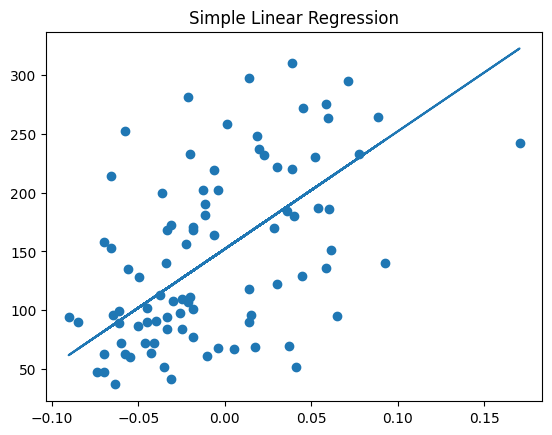

In [7]:
plt.scatter(X_test_s, y_test_s)
plt.plot(X_test_s, y_pred_lr)
plt.title("Simple Linear Regression")
plt.show()

In [8]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

metrics_multi = evaluate_model(y_test, y_pred_multi)
print("Multiple Regression Metrics:", metrics_multi)

Multiple Regression Metrics: (42.794094679599944, 2900.193628493482, np.float64(53.85344583676593), 0.4526027629719195)


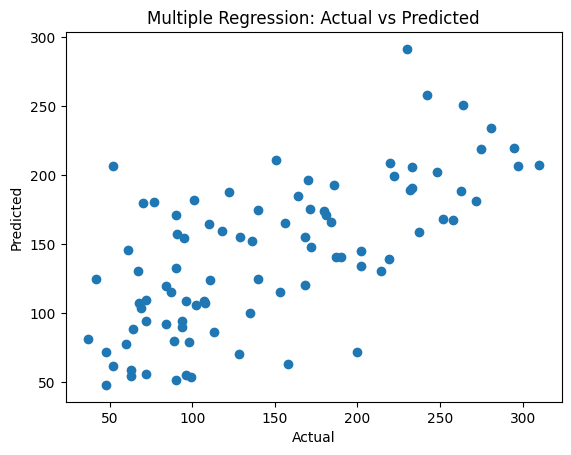

In [9]:
plt.scatter(y_test, y_pred_multi)
plt.title("Multiple Regression: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [10]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

y_pred_poly = model_poly.predict(X_poly_test)

metrics_poly = evaluate_model(y_test, y_pred_poly)
print("Polynomial Regression Metrics:", metrics_poly)

Polynomial Regression Metrics: (43.58169325465233, 3096.028307344272, np.float64(55.641965344012355), 0.4156399336408001)


In [11]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

metrics_ridge = evaluate_model(y_test, y_pred_ridge)
print("Ridge Regression Metrics:", metrics_ridge)

Ridge Regression Metrics: (46.13885766697452, 3077.41593882723, np.float64(55.47446204180109), 0.41915292635986545)


In [12]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

metrics_lasso = evaluate_model(y_test, y_pred_lasso)
print("Lasso Regression Metrics:", metrics_lasso)

Lasso Regression Metrics: (42.85442771664998, 2798.1934851697188, np.float64(52.897953506442185), 0.4718547867276227)


In [13]:
results = pd.DataFrame({
    "Model": ["Linear", "Multiple", "Polynomial", "Ridge", "Lasso"],
    "MAE": [metrics_lr[0], metrics_multi[0], metrics_poly[0], metrics_ridge[0], metrics_lasso[0]],
    "MSE": [metrics_lr[1], metrics_multi[1], metrics_poly[1], metrics_ridge[1], metrics_lasso[1]],
    "RMSE": [metrics_lr[2], metrics_multi[2], metrics_poly[2], metrics_ridge[2], metrics_lasso[2]],
    "R2": [metrics_lr[3], metrics_multi[3], metrics_poly[3], metrics_ridge[3], metrics_lasso[3]]
})

print(results)

        Model        MAE          MSE       RMSE        R2
0      Linear  52.259976  4061.825928  63.732456  0.233350
1    Multiple  42.794095  2900.193628  53.853446  0.452603
2  Polynomial  43.581693  3096.028307  55.641965  0.415640
3       Ridge  46.138858  3077.415939  55.474462  0.419153
4       Lasso  42.854428  2798.193485  52.897954  0.471855


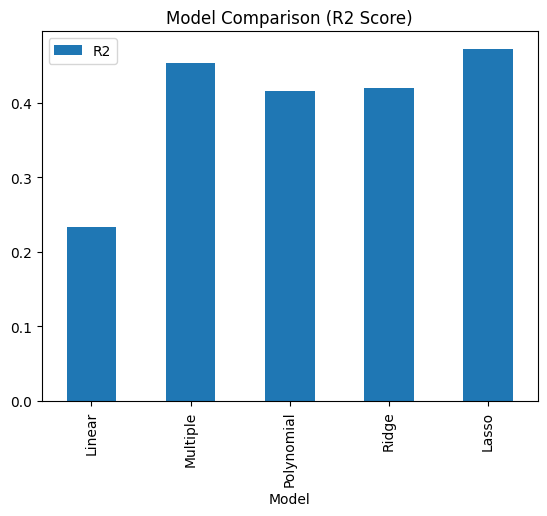

In [14]:
results.set_index("Model")[["R2"]].plot(kind="bar")
plt.title("Model Comparison (R2 Score)")
plt.show()